# **CH02 - 사이킷런**

# **05 데이터 전처리**

데이터 전처리(data preprocessing)  
-Null 값 처리  
-ml에서 문자열값을 허용하지 않기 때문에 숫자형으로 변환(문자열 피처는 카테고리형/텍스트형 피처로 나뉨)  

## <데이터 인코딩>

**레이블 인코딩**

-문자열인 카테고리 피처를 코드형 숫자 값으로 변환  
->예를 들어 상품 데이터의 상품 구분이 TV, 냉장고, 전자레인지, 컴퓨터, 선풍기, 믹서 값으로 돼 있다면 TV： 1, 냉장고: 2, 전자레인지: 3, 컴퓨터: 4, 선풍기: 5, 믹서: 6과 같은 숫자형 값으로 변환  

-LabelEncoder 클래스로 구현함.  
->LabelEncoder 객체 생성, fit()과 transform() 호출하여 수행 


In [35]:
from sklearn.preprocessing import LabelEncoder

items=['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '믹서', '믹서']

#LabelEncoder를 객체로 생성한 후 fit()과 transform()으로 레이블 인코딩 수행
encoder=LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
print('인코딩 변환값:', labels)

인코딩 변환값: [0 1 4 5 3 2 2]


In [36]:
#문자열 값이 어떤 숫자값으로 인코딩되었는지 classes 속성값으로 확인
print('인코딩 클래스:', encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [37]:
#inverse_transform으로 다시 디코딩 가능 
print('디코딩 원본값:', encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


**원-핫 인코딩**  
-피처값의 유형에 따라 새로운 피처를 추가해 고유 값에 해당하는 칼럼에만 1을 표시하고 나머지 칼럼에는 0을 표시  
-OneHotEncoder 클래스로 변환 가능  
->입력값으로 2차원 데이터 필요, 클래스로 변환한 값이 sparse matrix형태라서 toarray() 이용하여 dense matrix로 변환해야 함  

In [38]:
from sklearn.preprocessing import OneHotEncoder 
import numpy as np

items=['TV', '냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서', '믹서']

# 2차원 ndarray로 변환합니다.
items = np.array(items).reshape(-1, 1)
print(items)

# 원-핫 인코딩을 적용합니다.
oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

# OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환. 
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

[['TV']
 ['냉장고']
 ['전자레인지']
 ['컴퓨터']
 ['선풍기']
 ['선풍기']
 ['믹서']
 ['믹서']]
원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


**get_dummies() 이용**    
-더 빠르고 쉽게 원-핫 인코딩을 할 수 있음   

In [39]:
import pandas as pd

df = pd.DataFrame({'item':['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서'] 
})
pd.get_dummies(df, dtype=int)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,1,0,0,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,1,0
3,0,0,0,0,0,1
4,0,0,0,1,0,0
5,0,0,0,1,0,0
6,0,0,1,0,0,0
7,0,0,1,0,0,0


## <피처 스케일링과 정규화>

피처 스케일링(feature scaling) : 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업  
-표준화(standardization) -> {x_i-mean(x)}/stdev(x)  
-정규화(normalization)는 개별 데이터의 크기를 모두 똑같은 단위로 변경 -> {x_i-min(x)}/{max(x)-min(x)}  

-벡터 정규화 : 선형대수 개념 적용, 사이킷런의 전처리에서 제공하는 normalizer 모듈 -> x_i/sprt(x_i^2+y_i^2+z_i^2)  



**StandardScaler**  
표준화를 쉽게 지원하기 위한 클래스  
개별 피처를 평균=0 분산=1로 변환  


In [40]:
#데이터 확인

from sklearn.datasets import load_iris 
import pandas as pd

# 붓꽃 데이터 세트를 로딩하고 DataFrame으로 변환합니다.
iris = load_iris() 
iris_data = iris.data 
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)

print ('feature 들의 평균 값')
print(iris_df.mean())
print('\nfeature 들의 분산 값')
print(iris_df.var())

feature 들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature 들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [41]:
#표준화

from sklearn.preprocessing import StandardScaler

# StandardScaler객체 생성 
scaler = StandardScaler()
# StandardScaler로 데이터 세트 변환. fit( )과 transform( ) 호출.
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform( ) 시 스케일 변환된 데이터 세트가 NumPy ndarray로 반환돼 이를 DataFrame으로 변환 
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names) 
print ('feature 들의 평균 값') 
print(iris_df_scaled.mean()) 
print('\nfeature 들의 분산 값') 
print(iris_df_scaled.var()) 

feature 들의 평균 값
sepal length (cm)   -4.736952e-16
sepal width (cm)    -7.815970e-16
petal length (cm)   -4.263256e-16
petal width (cm)    -4.736952e-16
dtype: float64

feature 들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


**MinMaxScaler**  

정규화. 데이터값을 0과 1사이의 범위 값으로 변환(음수값있으면 -1에서 1사이 값)  


In [42]:
#정규화

from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler객체 생성 
scaler = MinMaxScaler()
# MinMaxScaler로 데이터 세트 변환. fit()과 transform() 호출. 
scaler.fit(iris_df) 
iris_scaled = scaler.transform(iris_df)

# transformO 시 스케일 변환된 데이터 세트가 NumPy ndarray로 반환돼 이를 DataFrame으로 변환 
iris_df_scaled = pd.DataFrame(data=iris_scaled,columns=iris.feature_names) 
print ('feature 들의 최솟값') 
print(iris_df_scaled.min()) 
print('\nfeature들의 최댓값') 
print(iris_df_scaled.max())

feature 들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feature들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


**학습/테스트 데이터의 스케일링 변환 시 유의점**  
StandardScaler와 MinMaxScaler와 같은 객체를 이용해 스케일링 변환 시 fit(), transform(), fit_transform() 메서드 이용  

fit()으로 데이터 변환을 위한 기준 정보 설정 적용, transform()으로 fit정보를 이용해 데이터 변환, fit_transform()은 두 메서드를 한번에 적용  

주의) 학습 데이터 세트로 fit, transform 적용하면 테스트 데이터로 fit 수행 x, 학습데이터의 fit으로 transform 변환을 적용 


In [43]:
from sklearn.preprocessing import MinMaxScaler 
import numpy as np

# 학습 데이터는 0부터 10까지, 테스트 데이터는 0부터 5까지 값을 가지는 데이터 세트로 생성
# Scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1, 1)로 차원 변경 
train_array = np.arange(0, 11).reshape(-1, 1) 
test_array = np.arange(0, 6).reshape(-1, 1)

In [44]:
# MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0~1 값으로 변환 
scaler = MinMaxScaler()

# fit()하게 되면 train.array 데이터의 최솟값이 0, 최댓값이 10으로 설정. 
scaler.fit(train_array)

# 1/10 scale로 train_array 데이터 변환함. 원본 10-> 1로 변환됨. 
train_scaled = scaler.transform(train_array)

print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2)) 
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [45]:
# MinMaxScaler에 test_array를 fit()하게 되면 원본 데이터의 최솟값이 0, 최댓값이 5로 설정됨 
scaler.fit(test_array)

# 1/5 scale로 test_array 데이터 변환함. 원본 5-〉1로 변환. 
test_scaled = scaler.transform(test_array)

# test_array의 scale 변환 출력 .
print('원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


In [46]:
scaler = MinMaxScaler()
scaler.fit(train_array) 
train_scaled = scaler.transform(train_array) 
print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2)) 
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))
      
# test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 함. 
test_scaled = scaler.transform(test_array)
print('\n원본 test_array 데이터:', np.round(test_array.reshape(-1), 2)) 
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


# **06 사이킷런으로 수행하는 타이타닉 생존자 예측**



In [47]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

titanic_df = pd.read_csv(r'C:\Users\chkwon\Data_Handling\titanic_train.csv') 
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [48]:
print('\n ### 학습 데이터 정보 ### \n') 
print(titanic_df.info())


 ### 학습 데이터 정보 ### 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
None


age, cabin, embarked 칼럼의 null값 처리  
-age는 평균 나이, 나머지 칼럼은 'N' 값으로 변경  

In [50]:
# 경고때문에 기존 코드 대신 아래와 같이 새롭게 작성
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('N')
titanic_df['Embarked'] = titanic_df['Embarked'].fillna('N')
print('데이터 세트 Null 값 개수', titanic_df.isnull().sum().sum())

데이터 세트 Null 값 개수 0


문자열 피처인 sex, cabin, embarked의 분포 확인  
-cabin의 분포가 이상하다는 것을 확인함->null값이 너무 많고 속성값이 제대로 정리가 되지 않은 상태 

In [52]:
print(' Sex 값 분포 ：\n', titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 ：\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 ：\n', titanic_df['Embarked'].value_counts())

 Sex 값 분포 ：
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 ：
 Cabin
N              687
G6               4
C23 C25 C27      4
B96 B98          4
F33              3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 ：
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


cabin 속성의 경우 앞 문자만 추출해보기

In [54]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1] 
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: str


성별에 따른 생존자수 확인해보기 

In [55]:
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

성별에 따른 생존자수 그래프로 확인해보기 

<Axes: xlabel='Sex', ylabel='Survived'>

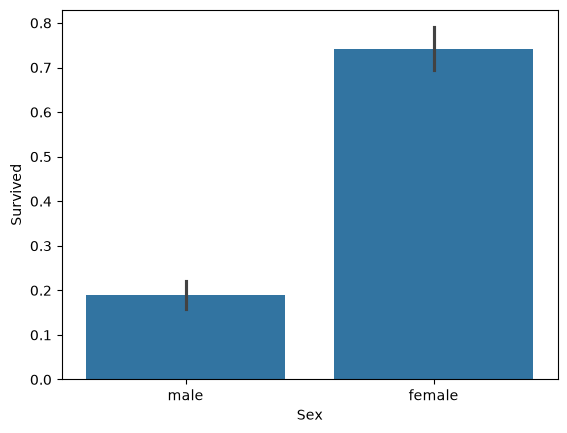

In [56]:
sns.barplot(x='Sex', y = 'Survived', data=titanic_df)

객실 등급별 성별에 따른 생존자수 확인하기 

<Axes: xlabel='Pclass', ylabel='Survived'>

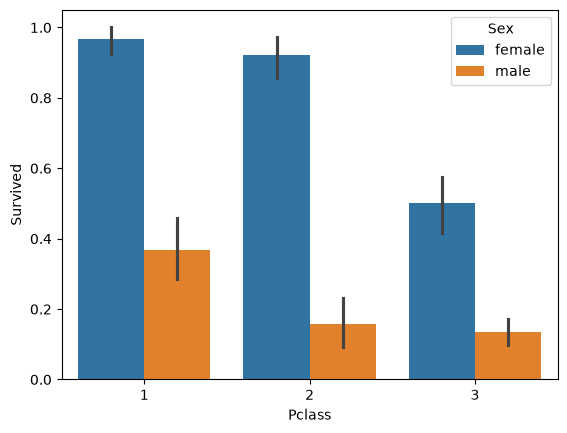

In [57]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

나이에 따른 생존자수 확인하기 

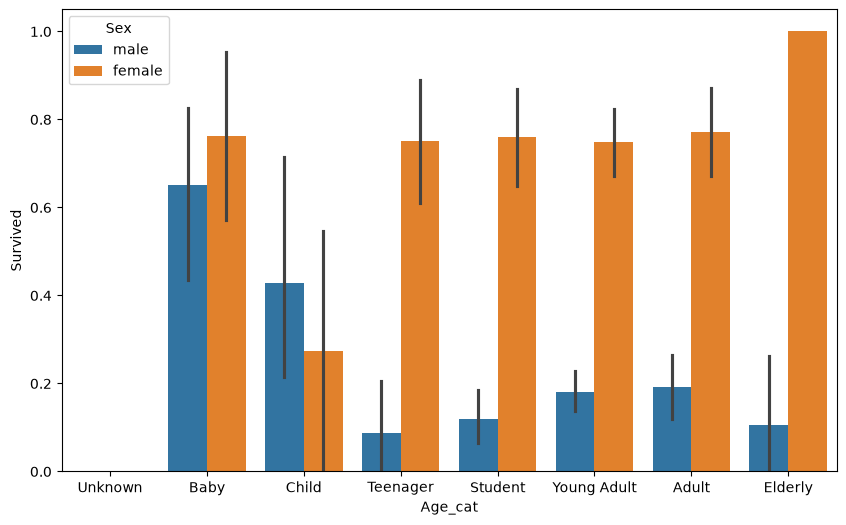

In [58]:
# 입력 age에 따라 구분 값을 반환하는 함수 설정. DataFrame의 apply lambda 식에 사용. 
def get_category(age):
    
    cat =''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'
    return cat

# 막대그래프의 크기 figure를 더 크게 설정 
plt.figure(figsize=(10, 6))
# 우축의 값을 순차적으로 표시하기 위한 설정
group_names = ['Unknown', 'Baby','Child', 'Teenager', 'Student', 'Young Adult','Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정.
# get_category(X)는 입력값으로 'Age' 칼럼 값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

문자열 카테고리 피처->숫자형 카테고리 피처로 변환, 레이블 인코딩 적용.  
여러 칼럼을 encode_features() 함수를 새로 생성하여 한 번에 변환  

In [59]:
from sklearn.preprocessing import LabelEncoder
def encode_features(dataDF):
    
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        
        le = LabelEncoder( )
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])
        
    return dataDF
    
titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


지금까지 피처를 가공한 내역을 정리하고 함수로 만들어 쉽게 재사용할 수 있게  

In [60]:
# Null 처리 함수 
def fillna(df):
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')
    df['Fare'] = df['Fare'].fillna(0)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거 
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True) 
    return df
    
# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1] 
    features = ['Cabin', 'Sex', 'Embarked'] 
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature]) 
    return df

# 앞에서 설정한 데이터 전처리 함수 호출 
def transform_features(df) :
    
    df = fillna(df)
    df = drop_features(df) 
    df = format_features(df) 
    return df

데이터 전처리를 수행하는 transform_features() 함수를 이용하여 원본 데이터 다시 가공  
-레이블인 survived 속성만 따로 분리하여 레이블 데이터 세트로 만들어줌  
-레이블을 제외한 피처 데이터 세트에만 해당 함수 적용  

In [61]:
# 원본 데이터를 재로딩하고, 피처 데이터 세트와 레이블 데이터 세트 추출.
titanic_df = pd.read_csv(r'C:\Users\chkwon\Data_Handling\titanic_train.csv') 
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

학습/테스트 데이터로 분리 

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df, 
test_size=0.2, random_state=11)

ml 알고리즘인 결정 트리, 랜덤 포레스트, 로지스틱 회귀를 이용하여 타이타닉 생존자를 예측해보기  

-아직 최적화 작업도 수행하지 않았고 데이터양도 적어서 성능을 판단할 수 없지만, 우선 로지스틱 회귀 알고리즘이 가장 높은 정확도를 보임  

In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score

# 결정트리, Random Forest, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성 
dt_clf = DecisionTreeClassifier(random_state=11) 
rf_clf = RandomForestClassifier(random_state=11) 
lr_clf = LogisticRegression(solver='liblinear') #로지스틱 회귀의 최적화 알고리즘을 liblinear로 설정 

# DecisionTreeClassifier 학습/예측/평가 
dt_clf.fit(X_train, y_train) 
dt_pred = dt_clf.predict(X_test)
print( 'DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 학습/예측/평가 
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

# LogisticRegression 학습/예측/평가 
lr_clf.fit(X_train, y_train) 
lr_pred = lr_clf.predict(X_test) 
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659


교차 검증으로 의사결정트리 모델을 평가해보기 

-KFold : 폴드 5개로 설정, 정확도 78.23%  
-cross_val_score() : StratifiedFold를 이용하기 때문에 정확도가 케이폴드와 다름, 78.79%  
-GridSearchCV : 최적 하이퍼 파라미터를 찾고 예측 성능 측정함, CV 5개, 하이퍼 파라미터는 max_depth, min_samples_splot, min_samples_leaf를 변경하면서 측정 

In [64]:
from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    # 폴드 세트를 5개인 KFold 객체를 생성, 폴드 수만큼 예측결과 저장을 위한 리스트 객체 생성.
    kfold = KFold(n_splits=folds) 
    scores = []
    
    # KFold 교차 검증 수행.
    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)): 
        # X_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성 
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index] 
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index] 
        
        # Classifier 학습, 예측, 정확도 계산 
        clf.fit(X_train, y_train) 
        predictions = clf.predict(X_test) 
        accuracy = accuracy_score(y_test, predictions) 
        scores.append(accuracy)
        print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))
    # 5개 fold에서의 평균 정확도 계산.
    mean_score = np.mean(scores)
    print("평균 정확도: {0:.4f}".format(mean_score))
# exec_kfold 호출
exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


In [65]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)

for iter_count, accuracy in enumerate (scores):
    print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

print("평균 정확도: {0:.4f}".format(np.mean(scores)))

교차 검증 0 정확도: 0.7430
교차 검증 1 정확도: 0.7753
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7865
교차 검증 4 정확도: 0.8427
평균 정확도: 0.7879


In [66]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth' :[2, 3, 5, 10], 
'min_samples_split':[2, 3, 5], 'min_samples_leaf':[1, 5, 8]}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy',cv=5) 
grid_dclf.fit(X_train, y_train)

print('GridSearchCV 최적 하이퍼 파라미터 :', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_)) 
best_dclf = grid_dclf.best_estimator_

# GridSearchCV의 최적 하이퍼 파라미터로 학습된 Estimator로 예측 및 평가 수행. 
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}' .format(accuracy))

GridSearchCV 최적 하이퍼 파라미터 : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715
